**Capstone Project - 1**

-------







# Predictive Maintenance Project
---

**Problem Statement  :** The goal of this project is to build a machine learning model to predict whether a machine is likely to experience a failure based on real-time sensor data. This is crucial for implementing predictive maintenance strategies, which help in reducing downtime, improving efficiency, and minimizing operational costs. Candidate will analyze the dataset, explore relationships between variables, and develop a classification model to predict the "Target" variable, which indicates whether a machine will fail or not.


**Objective  :** Build a classification model using classification algorithms and compare their performances to predict whether a machine is likely to experience a failure or not.


**Dataset Overview  :** The dataset consists of 21 records and 9 columns. Each row represents a machine’s operational status under specific conditions. The task is to use the provided variables to predict the likelihood of a machine failure.

---


In [1]:
!pip install xgboost imbalanced-learn

In [4]:
# Core
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    f1_score, precision_score, recall_score, accuracy_score
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# Imbalanced data handling
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV

np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
print('All libraries imported successfully')

All libraries imported successfully


In [7]:
# Load Dataset

df = pd.read_csv(r'D:\Data_Science\Final_Work\Capstone_Project\Predictive Maintenance\predictive_maintenance.csv')

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
0,1,M14860,M,298.1,308.6,1551,42.8,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0


In [8]:
df.shape

(10000, 9)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 703.3+ KB


In [10]:
df.describe().round(3)

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000
mean,5000.500,300.005,310.006,1538.776,39.987,107.951,0.034
std,2886.896,2.000,1.484,179.284,9.969,63.654,0.181
min,1.000,295.300,305.700,1168.000,3.800,0.000,0.000
25%,2500.750,298.300,308.800,1423.000,33.200,53.000,0.000
50%,5000.500,300.100,310.100,1503.000,40.100,108.000,0.000
75%,7500.250,301.500,311.100,1612.000,46.800,162.000,0.000
max,10000.000,304.500,313.800,2886.000,76.600,253.000,1.000


### Exploratory Data Analysis (EDA)
---

In [11]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
dtype: int64

In [12]:
print(f'\nDuplicate rows: {df.duplicated().sum()}')


Duplicate rows: 0


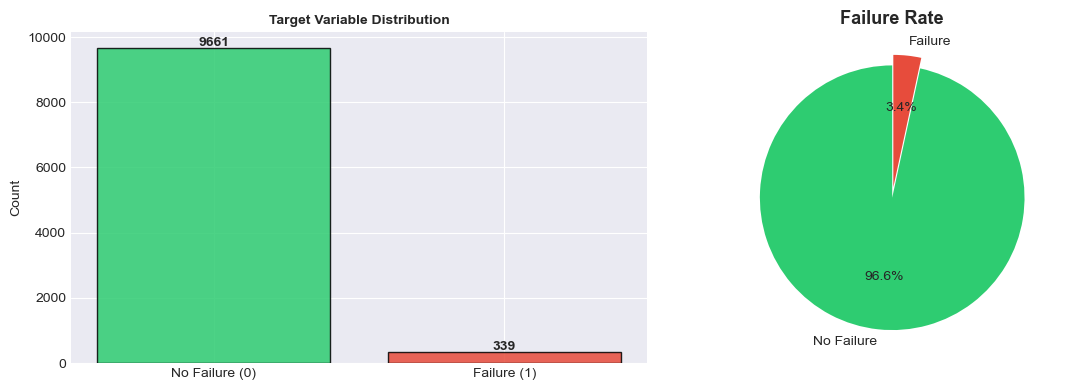

Failure rate: 3.39% - Highly Imbalanced!
Class ratio: 9661:339 = 28:1


In [14]:
# Target Distribution 

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['Target'].value_counts()
axes[0].bar(['No Failure (0)', 'Failure (1)'], counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black', alpha=0.85)
axes[0].set_title('Target Variable Distribution', fontweight='bold', fontsize=10)
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['No Failure', 'Failure'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, explode=(0, 0.08))
axes[1].set_title('Failure Rate', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Failure rate: {counts[1]/len(df)*100:.2f}% - Highly Imbalanced!')
print(f'Class ratio: {counts[0]}:{counts[1]} = {counts[0]//counts[1]}:1')

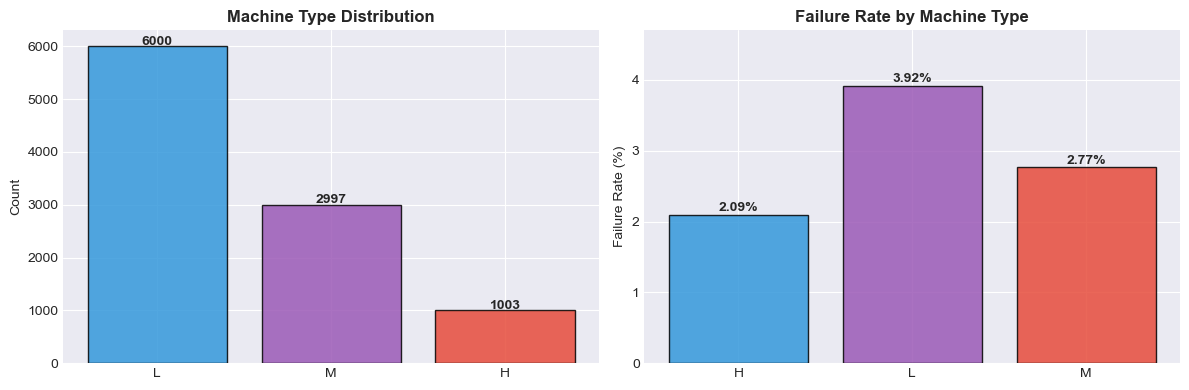

In [15]:
# Machine Type Distribution 

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

type_counts = df['Type'].value_counts()
axes[0].bar(type_counts.index, type_counts.values,
            color=['#3498db', '#9b59b6', '#e74c3c'], edgecolor='black', alpha=0.85)
axes[0].set_title('Machine Type Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, (t, v) in enumerate(zip(type_counts.index, type_counts.values)):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Failure rate by type
fail_by_type = df.groupby('Type')['Target'].mean() * 100
bars = axes[1].bar(fail_by_type.index, fail_by_type.values,
                   color=['#3498db', '#9b59b6', '#e74c3c'], edgecolor='black', alpha=0.85)
axes[1].set_title('Failure Rate by Machine Type', fontweight='bold')
axes[1].set_ylabel('Failure Rate (%)')
axes[1].set_ylim(0, fail_by_type.max() * 1.2)
for bar, val in zip(bars, fail_by_type.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('type_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

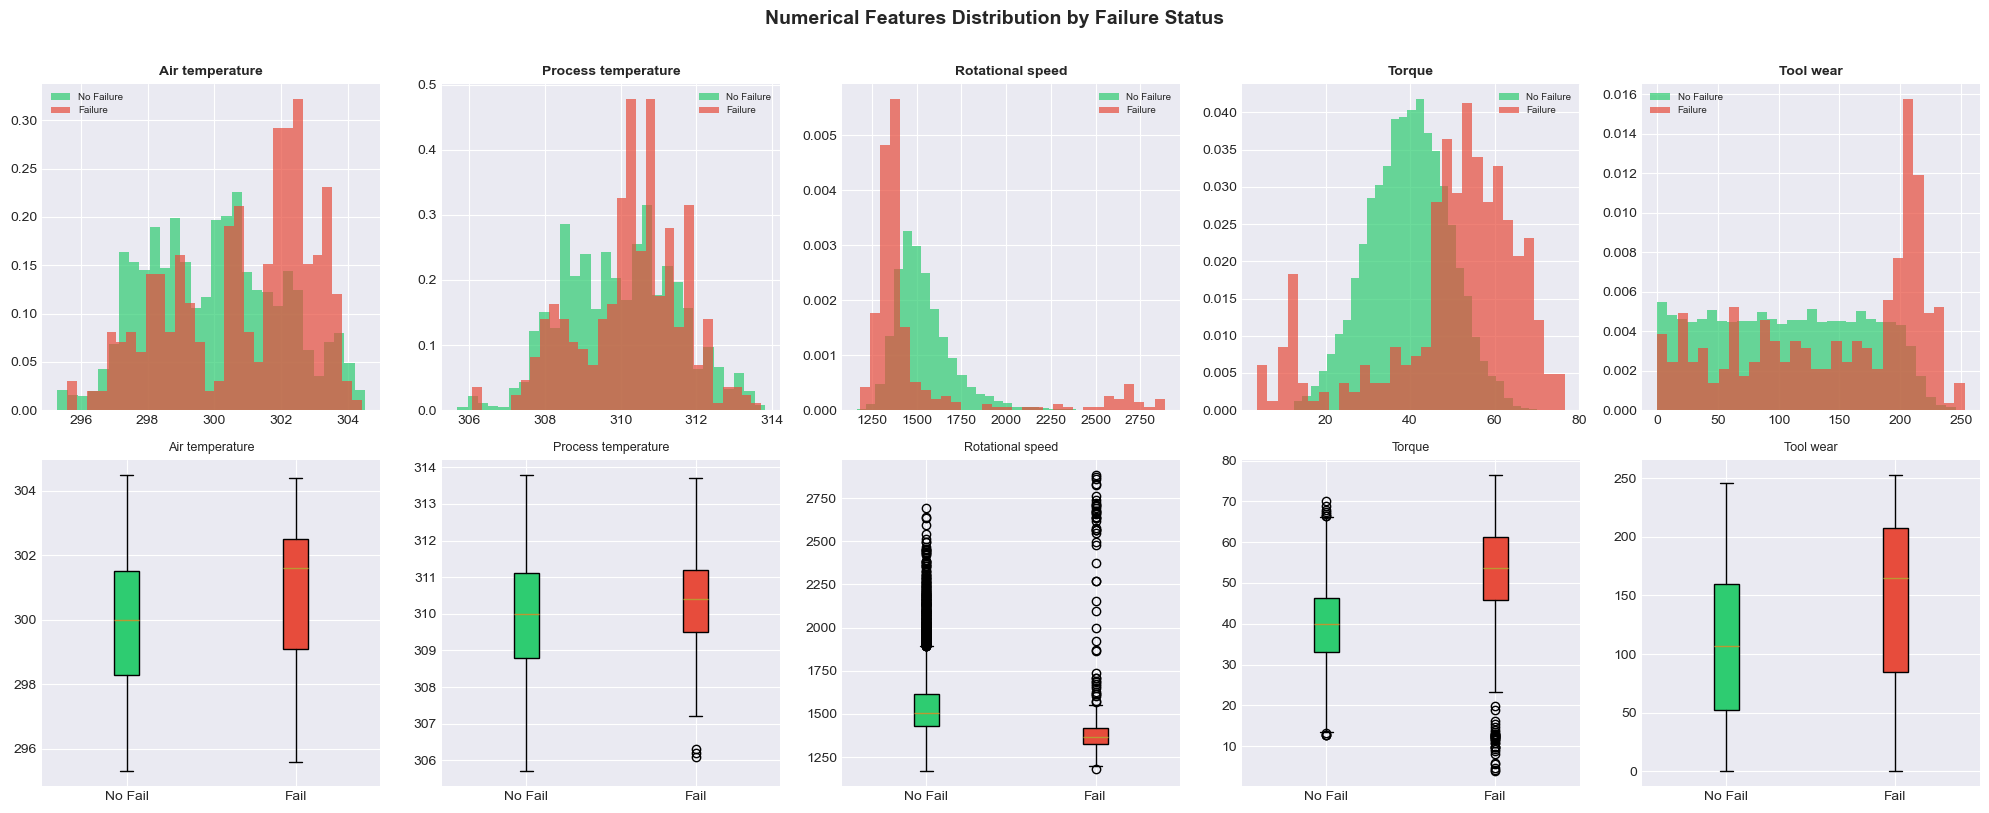

In [16]:
# Numerical Features Distribution

num_features = ['Air temperature [K]', 'Process temperature [K]',
                'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for i, feat in enumerate(num_features):
    # Histogram by class
    axes[0][i].hist(df[df['Target']==0][feat], bins=30, alpha=0.7,
                    color='#2ecc71', label='No Failure', density=True)
    axes[0][i].hist(df[df['Target']==1][feat], bins=30, alpha=0.7,
                    color='#e74c3c', label='Failure', density=True)
    axes[0][i].set_title(feat.split('[')[0].strip(), fontsize=10, fontweight='bold')
    axes[0][i].legend(fontsize=7)

    # Boxplot
    data_plot = [df[df['Target']==0][feat], df[df['Target']==1][feat]]
    bp = axes[1][i].boxplot(data_plot, labels=['No Fail', 'Fail'], patch_artist=True)
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    axes[1][i].set_title(feat.split('[')[0].strip(), fontsize=9)

plt.suptitle('Numerical Features Distribution by Failure Status',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

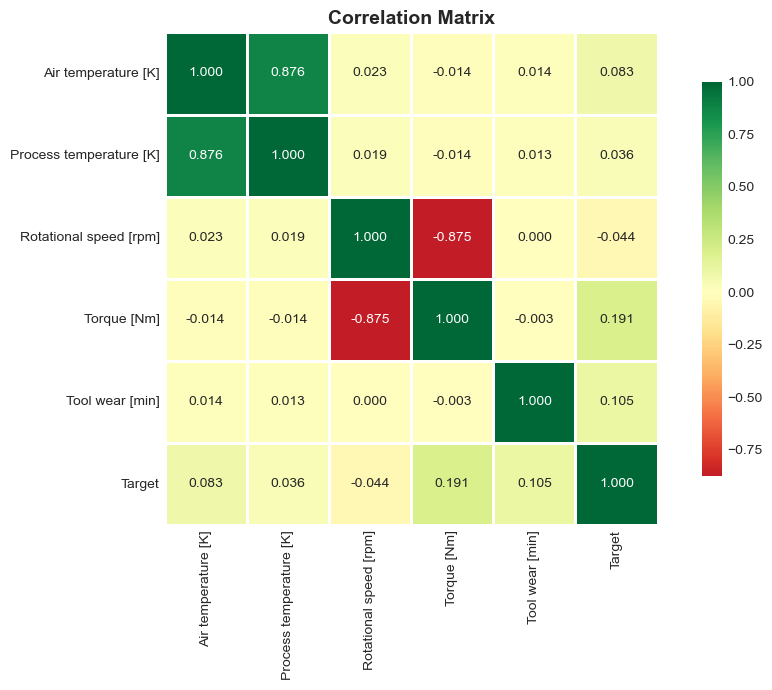

Correlation with Target (failure):
Torque [Nm]                0.191321
Tool wear [min]            0.105448
Air temperature [K]        0.082556
Process temperature [K]    0.035946
Rotational speed [rpm]    -0.044188
Name: Target, dtype: float64


In [18]:
# Correlation Heatmap 

plt.figure(figsize=(10, 7))
corr_cols = num_features + ['Target']
corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.3f',
            cmap='RdYlGn', center=0, square=True,
            linewidths=1, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Correlation with Target (failure):')
print(corr['Target'].drop('Target').sort_values(ascending=False))

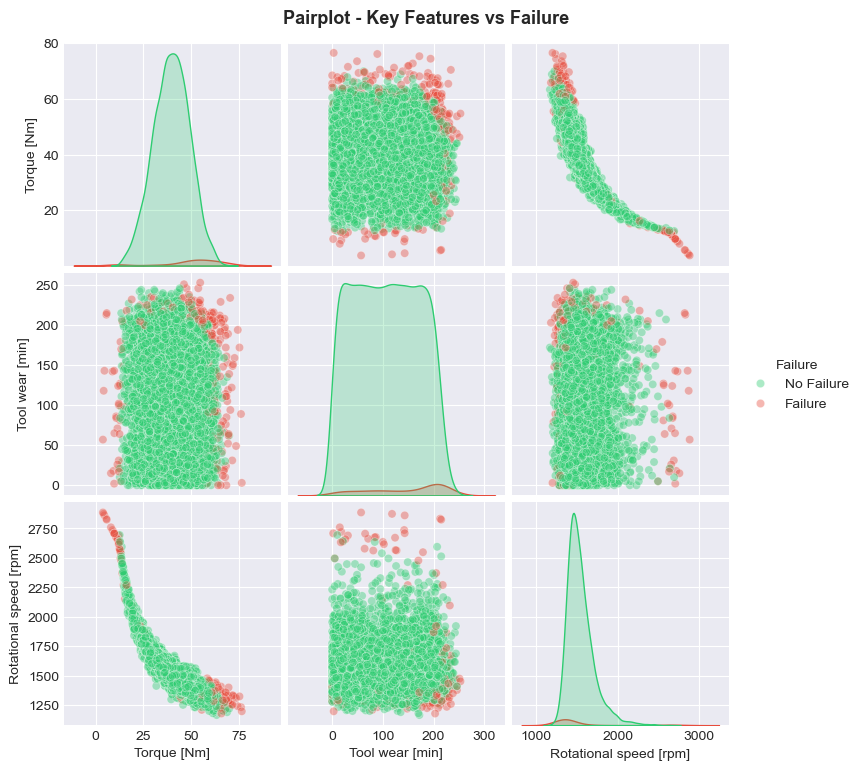

In [20]:
# Feature Pair Plot: Key Features 

key_features = ['Torque [Nm]', 'Tool wear [min]', 'Rotational speed [rpm]', 'Target']
pair_df = df[key_features].copy()
pair_df['Failure'] = pair_df['Target'].map({0: 'No Failure', 1: 'Failure'})

g = sns.pairplot(pair_df.drop('Target', axis=1), hue='Failure',
                 palette={'No Failure': '#2ecc71', 'Failure': '#e74c3c'},
                 diag_kind='kde', plot_kws={'alpha': 0.4})
g.fig.suptitle('Pairplot - Key Features vs Failure', y=1.02,
                fontsize=13, fontweight='bold')
plt.savefig('pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

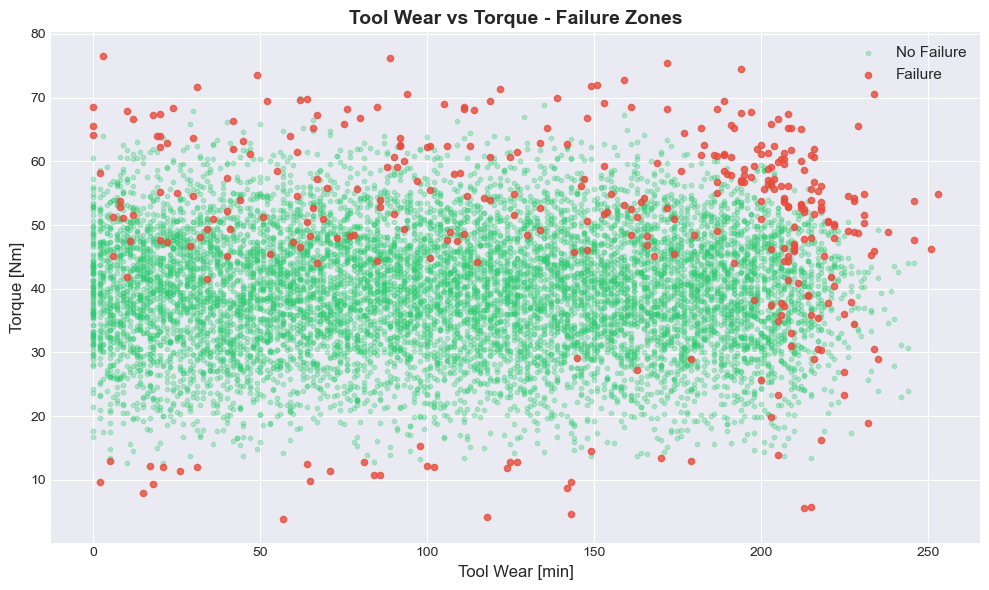

In [21]:
# Tool Wear vs Torque (failure zone) 

plt.figure(figsize=(10, 6))
no_fail = df[df['Target'] == 0]
fail    = df[df['Target'] == 1]

plt.scatter(no_fail['Tool wear [min]'], no_fail['Torque [Nm]'],
            c='#2ecc71', alpha=0.3, s=10, label='No Failure')
plt.scatter(fail['Tool wear [min]'], fail['Torque [Nm]'],
            c='#e74c3c', alpha=0.8, s=20, label='Failure', zorder=5)
plt.xlabel('Tool Wear [min]', fontsize=12)
plt.ylabel('Torque [Nm]', fontsize=12)
plt.title('Tool Wear vs Torque - Failure Zones', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('failure_zones.png', dpi=150, bbox_inches='tight')
plt.show()

### Skewness Check and Outlier Treatment
---

In [22]:
# Skewness 

print('Skewness of numerical features:')

for col in num_features:
    skew = df[col].skew()
    flag = '← HIGH SKEW' if abs(skew) > 1 else '← Moderate' if abs(skew) > 0.5 else ''
    print(f'{col.split("[")[0].strip():30s}: {skew:+.4f}  {flag}')

Skewness of numerical features:
Air temperature               : +0.1143  
Process temperature           : +0.0150  
Rotational speed              : +1.9932  ← HIGH SKEW
Torque                        : -0.0095  
Tool wear                     : +0.0273  


In [23]:
# Outlier Detection - IQR 

print('Outlier Detection (IQR Method):')

for col in num_features:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f'{col.split("[")[0].strip():30s}: {n_out:4d} outliers ({n_out/len(df)*100:.2f}%)')

Outlier Detection (IQR Method):
Air temperature               :    0 outliers (0.00%)
Process temperature           :    0 outliers (0.00%)
Rotational speed              :  418 outliers (4.18%)
Torque                        :   69 outliers (0.69%)
Tool wear                     :    0 outliers (0.00%)


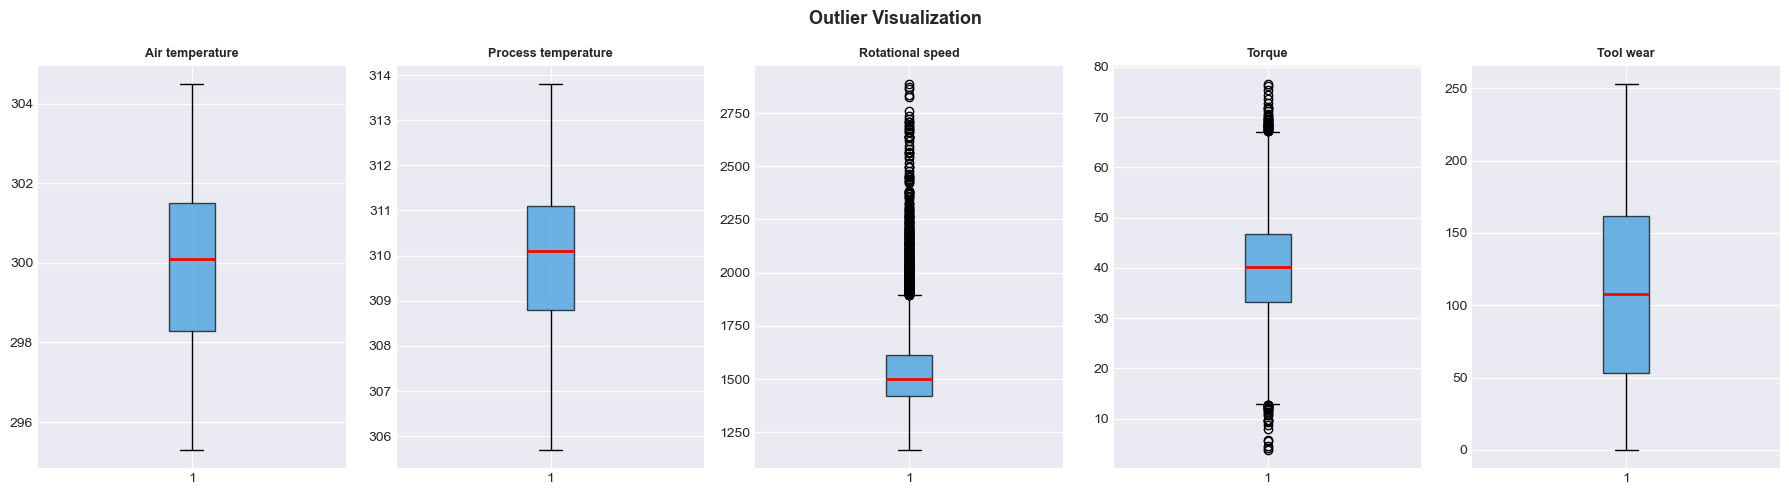

In [24]:
# Outlier Detection - Box Plot 

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for i, col in enumerate(num_features):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='#3498db', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col.split('[')[0].strip(), fontweight='bold', fontsize=9)
plt.suptitle('Outlier Visualization', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outlier_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# Outlier treatment - Winsorization 

df_clean = df.copy()
for col in ['Rotational speed [rpm]', 'Torque [Nm]']:
    p1, p99 = df_clean[col].quantile(0.01), df_clean[col].quantile(0.99)
    df_clean[col] = df_clean[col].clip(p1, p99)
    print(f'{col}: clipped to [{p1:.1f}, {p99:.1f}]')
print('\nOutlier treatment complete ')

Rotational speed [rpm]: clipped to [1275.0, 2188.0]
Torque [Nm]: clipped to [16.7, 62.8]

Outlier treatment complete 


### Feature Engineering and Preprocessing
---

In [26]:
# Feature Engineering

df_model = df_clean.copy()

# Temperature difference - process vs air
df_model['Temp_Diff'] = df_model['Process temperature [K]'] - df_model['Air temperature [K]']

# Power = Torque × Rotational speed (proxy for mechanical power)
df_model['Power'] = df_model['Torque [Nm]'] * df_model['Rotational speed [rpm]']

# Tool wear × Torque (wear under load)
df_model['Wear_Torque'] = df_model['Tool wear [min]'] * df_model['Torque [Nm]']

print('New features created:')
print('  Temp_Diff    = Process temp - Air temp')
print('  Power        = Torque × Rotational speed')
print('  Wear_Torque  = Tool wear × Torque')
print(f'\nDataset shape after feature engineering: {df_model.shape}')

New features created:
  Temp_Diff    = Process temp - Air temp
  Power        = Torque × Rotational speed
  Wear_Torque  = Tool wear × Torque

Dataset shape after feature engineering: (10000, 12)


In [27]:
# Encode categorical + drop irrelevant 

# Drop UDI and Product ID
df_model = df_model.drop(['UDI', 'Product ID'], axis=1)

# Encode Type (L=0, M=1, H=2)
le = LabelEncoder()
df_model['Type'] = le.fit_transform(df_model['Type'])
print('Type encoding:', dict(zip(le.classes_, le.transform(le.classes_))))

print(f'\nFeatures: {df_model.drop("Target", axis=1).columns.tolist()}')
print(f'Dataset shape: {df_model.shape}')

Type encoding: {'H': np.int64(0), 'L': np.int64(1), 'M': np.int64(2)}

Features: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Temp_Diff', 'Power', 'Wear_Torque']
Dataset shape: (10000, 10)


In [28]:
# Train-Test Split

X = df_model.drop('Target', axis=1)
y = df_model['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples')
print(f'Train failure rate: {y_train.mean()*100:.2f}%')
print(f'Test failure rate:  {y_test.mean()*100:.2f}%')

Train: 8000 samples | Test: 2000 samples
Train failure rate: 3.39%
Test failure rate:  3.40%


In [29]:
#  Feature Scaling

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print('StandardScaler applied')

StandardScaler applied


### Handle Class Imbalance - SMOTE
---

In [30]:
# Apply SMOTE 

print('Before SMOTE:')
print(f'  No Failure: {(y_train==0).sum()}')
print(f'  Failure:    {(y_train==1).sum()}')
print(f'  Ratio:      {(y_train==0).sum()/(y_train==1).sum():.1f}:1')

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print('\nAfter SMOTE:')
print(f'  No Failure: {(y_train_sm==0).sum()}')
print(f'  Failure:    {(y_train_sm==1).sum()}')
print(f'  Ratio:      {(y_train_sm==0).sum()/(y_train_sm==1).sum():.1f}:1')

Before SMOTE:
  No Failure: 7729
  Failure:    271
  Ratio:      28.5:1

After SMOTE:
  No Failure: 7729
  Failure:    7729
  Ratio:      1.0:1


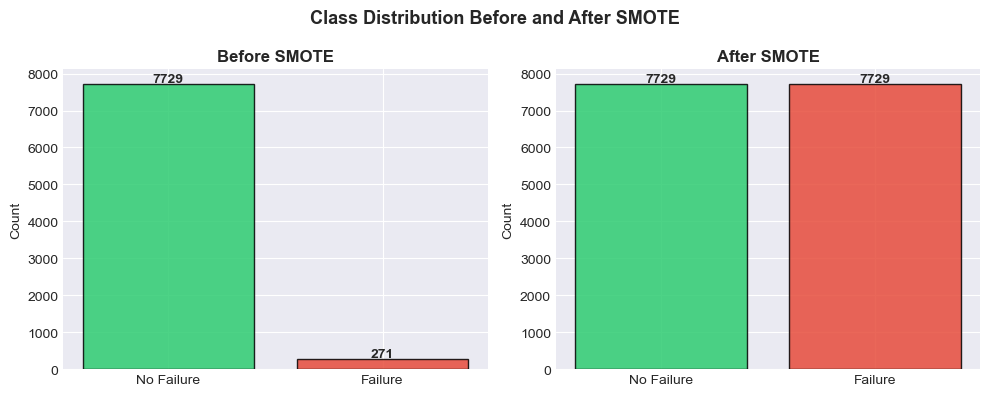

In [31]:
# Visualize class balance before/after SMOTE

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Before
before = pd.Series(y_train).value_counts()
axes[0].bar(['No Failure', 'Failure'], before.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black', alpha=0.85)
axes[0].set_title('Before SMOTE', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(before.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# After
after = pd.Series(y_train_sm).value_counts()
axes[1].bar(['No Failure', 'Failure'], after.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black', alpha=0.85)
axes[1].set_title('After SMOTE', fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(after.values):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.suptitle('Class Distribution Before and After SMOTE',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('smote_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Build and Train Classification Models
---

In [32]:
# Define all models 

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=100, random_state=42,
                                         eval_metric='logloss', verbosity=0),
    'SVM':                 SVC(kernel='rbf', probability=True, random_state=42),
    'KNN':                 KNeighborsClassifier(n_neighbors=5),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42)
}
print(f'{len(models)} models defined')
for name in models:
    print(f'  - {name}')

6 models defined
  - Logistic Regression
  - Random Forest
  - XGBoost
  - SVM
  - KNN
  - Gradient Boosting


In [33]:
# Train and evaluate all models 

results = []

for name, model in models.items():
    print(f'Training {name}...', end=' ')
    
    # Train on SMOTE data
    model.fit(X_train_sm, y_train_sm)
    
    # Predict on original (unbalanced) test set
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    # Metrics
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_prob)
    
    results.append({
        'Model': name,
        'Accuracy': round(acc*100, 2),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1 Score': round(f1, 4),
        'ROC-AUC': round(auc, 4)
    })
    print(f'Done - Accuracy: {acc*100:.2f}% | Recall: {rec:.3f} | AUC: {auc:.3f}')

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
print('\nAll models trained')

Training Logistic Regression... Done - Accuracy: 85.75% | Recall: 0.853 | AUC: 0.931
Done - Accuracy: 96.90% | Recall: 0.779 | AUC: 0.970
Done - Accuracy: 97.20% | Recall: 0.765 | AUC: 0.971
Done - Accuracy: 92.10% | Recall: 0.882 | AUC: 0.966
Done - Accuracy: 93.05% | Recall: 0.735 | AUC: 0.873
Done - Accuracy: 94.60% | Recall: 0.882 | AUC: 0.975

All models trained


In [34]:
# Results table

print('Model Performance Comparison:')

print(results_df.to_string(index=False))
print('\nNote: Recall = most important metric - missing a failure is costly!')

Model Performance Comparison:
              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
  Gradient Boosting     94.60     0.3750  0.8824    0.5263   0.9746
            XGBoost     97.20     0.5652  0.7647    0.6500   0.9712
      Random Forest     96.90     0.5300  0.7794    0.6310   0.9704
                SVM     92.10     0.2857  0.8824    0.4317   0.9659
Logistic Regression     85.75     0.1742  0.8529    0.2893   0.9311
                KNN     93.05     0.2924  0.7353    0.4184   0.8729

Note: Recall = most important metric - missing a failure is costly!


In [35]:
# Cross-validation on best models

print('5-Fold Cross-Validation (on SMOTE training data):')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

top_models = ['Random Forest', 'XGBoost', 'Gradient Boosting']
for name in top_models:
    model = models[name]
    scores = cross_val_score(model, X_train_sm, y_train_sm,
                             cv=cv, scoring='roc_auc')
    print(f'{name:25s}: {scores.mean():.4f} ± {scores.std():.4f}')

5-Fold Cross-Validation (on SMOTE training data):
Random Forest            : 0.9982 ± 0.0003
XGBoost                  : 0.9988 ± 0.0002
Gradient Boosting        : 0.9921 ± 0.0018


### Visualize Model Performance
---

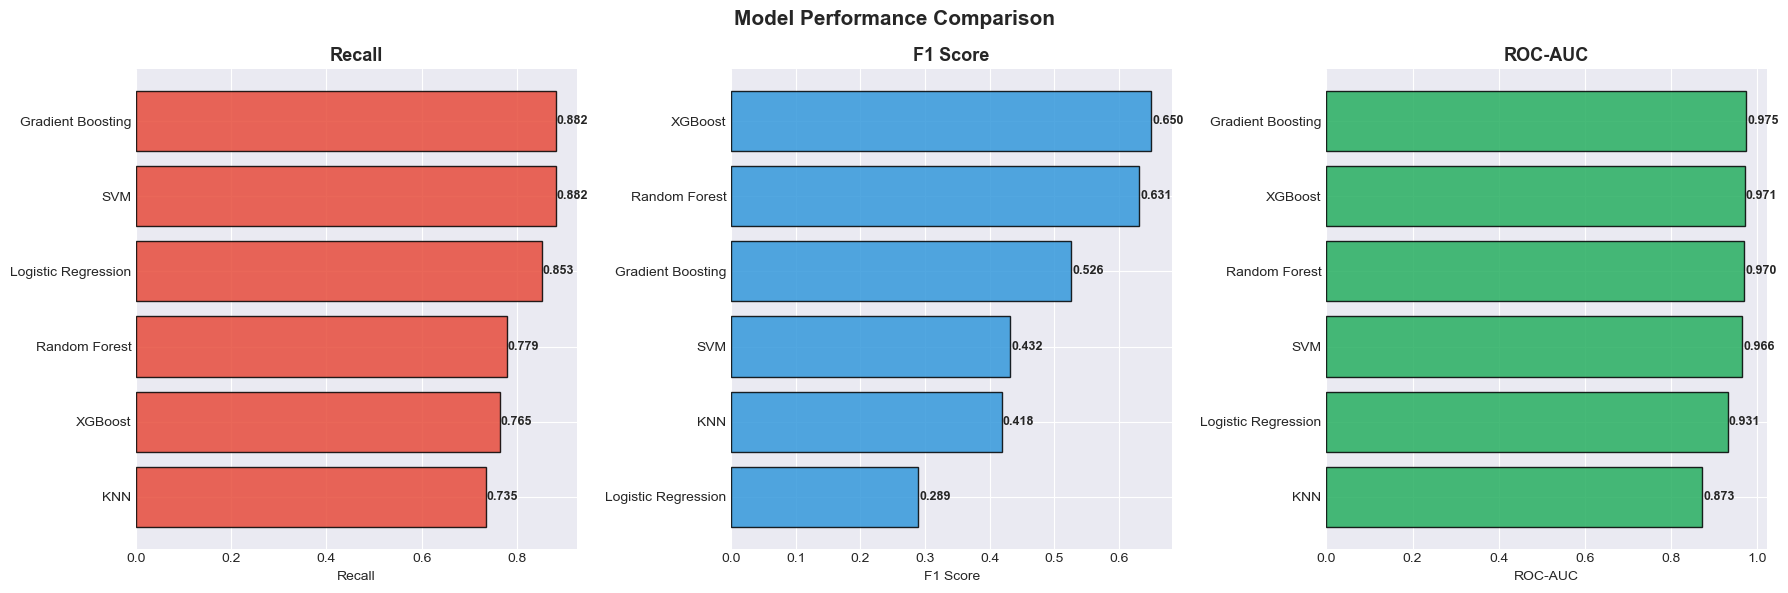

In [36]:
# Bar chart comparison 

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics = ['Recall', 'F1 Score', 'ROC-AUC']
colors_bar = ['#e74c3c', '#3498db', '#27ae60']

for ax, metric, color in zip(axes, metrics, colors_bar):
    sorted_df = results_df.sort_values(metric, ascending=True)
    bars = ax.barh(sorted_df['Model'], sorted_df[metric],
                   color=color, edgecolor='black', alpha=0.85)
    ax.set_title(metric, fontweight='bold', fontsize=13)
    ax.set_xlabel(metric)
    for bar, val in zip(bars, sorted_df[metric]):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9, fontweight='bold')

plt.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

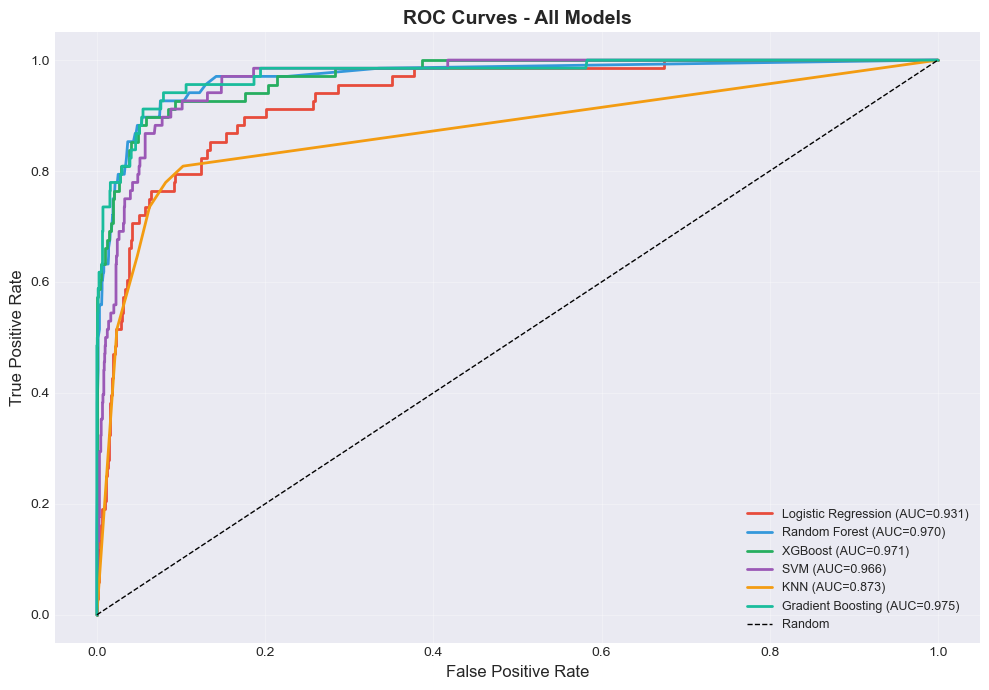

In [37]:
# ROC Curves

plt.figure(figsize=(10, 7))
colors_roc = ['#e74c3c','#3498db','#27ae60','#9b59b6','#f39c12','#1abc9c']

for (name, model), color in zip(models.items(), colors_roc):
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, linewidth=2)

plt.plot([0,1],[0,1],'k--', linewidth=1, label='Random')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - All Models', fontsize=14, fontweight='bold')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

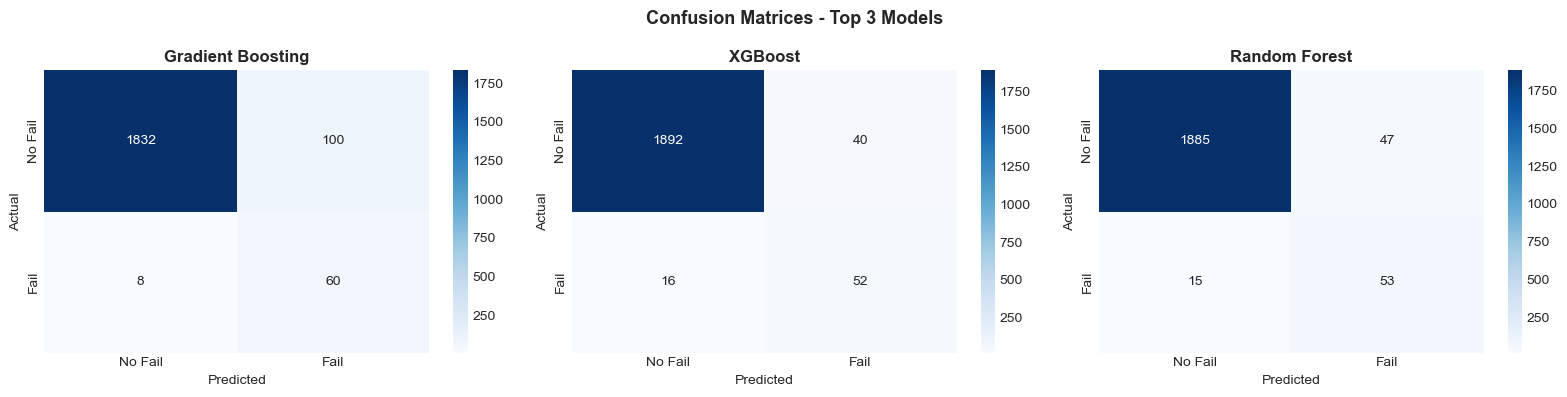

In [38]:
# Confusion Matrices - Top 3 models

top3 = results_df.head(3)['Model'].tolist()
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, name in zip(axes, top3):
    y_pred = models[name].predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Fail','Fail'],
                yticklabels=['No Fail','Fail'])
    ax.set_title(name, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices - Top 3 Models',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### Hyperparameter Tuning - Best Model
---

In [39]:
# GridSearchCV on XGBoost

print('Hyperparameter tuning XGBoost with GridSearchCV')

param_grid = {
    'n_estimators':  [100, 200],
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample':     [0.8, 1.0]
}

xgb_base = XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0)
grid_search = GridSearchCV(
    xgb_base, param_grid,
    cv=3, scoring='roc_auc',
    n_jobs=-1, verbose=1
)
grid_search.fit(X_train_sm, y_train_sm)

print(f'\nBest params: {grid_search.best_params_}')
print(f'Best CV AUC: {grid_search.best_score_:.4f}')

Hyperparameter tuning XGBoost with GridSearchCV
Fitting 3 folds for each of 36 candidates, totalling 108 fits

Best params: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Best CV AUC: 0.9988


In [40]:
# Evaluate tuned model

best_xgb = grid_search.best_estimator_
y_pred_tuned = best_xgb.predict(X_test_scaled)
y_prob_tuned = best_xgb.predict_proba(X_test_scaled)[:, 1]

print('Tuned XGBoost - Test Performance:')
print(f'  Accuracy:  {accuracy_score(y_test, y_pred_tuned)*100:.2f}%')
print(f'  Precision: {precision_score(y_test, y_pred_tuned):.4f}')
print(f'  Recall:    {recall_score(y_test, y_pred_tuned):.4f}')
print(f'  F1 Score:  {f1_score(y_test, y_pred_tuned):.4f}')
print(f'  ROC-AUC:   {roc_auc_score(y_test, y_prob_tuned):.4f}')
print()
print(classification_report(y_test, y_pred_tuned,
                             target_names=['No Failure', 'Failure']))

Tuned XGBoost - Test Performance:
  Accuracy:  97.30%
  Precision: 0.5833
  Recall:    0.7206
  F1 Score:  0.6447
  ROC-AUC:   0.9711

              precision    recall  f1-score   support

  No Failure       0.99      0.98      0.99      1932
     Failure       0.58      0.72      0.64        68

    accuracy                           0.97      2000
   macro avg       0.79      0.85      0.82      2000
weighted avg       0.98      0.97      0.97      2000



### Feature Importance
---

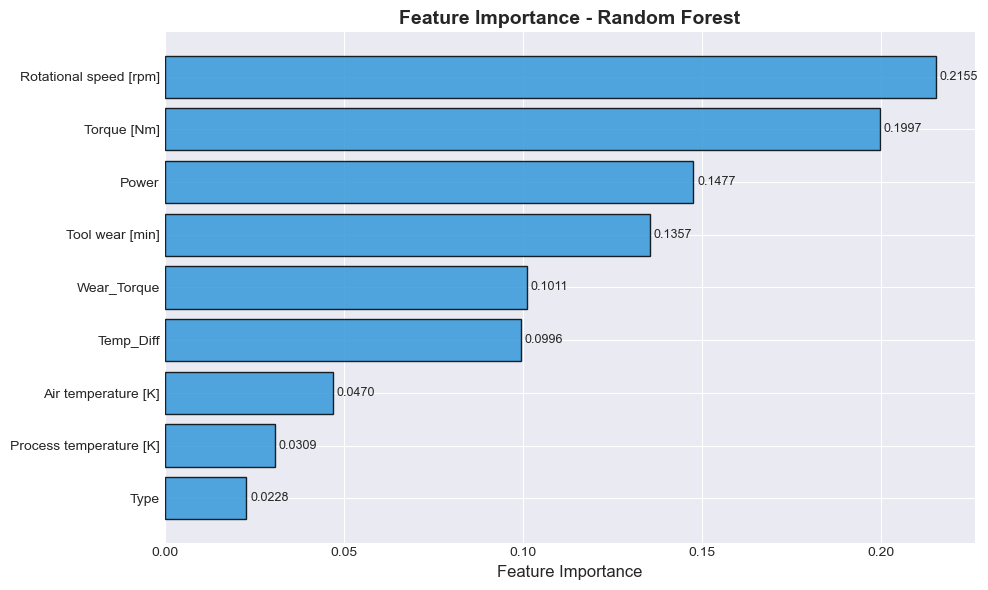

Top 3 predictors of machine failure:
  Rotational speed [rpm]: 0.2155
  Torque [Nm]: 0.1997
  Power: 0.1477


In [41]:
#  Feature importance — Random Forest 

rf_model = models['Random Forest']
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.barh(feat_imp['Feature'], feat_imp['Importance'],
                color='#3498db', edgecolor='black', alpha=0.85)
plt.xlabel('Feature Importance', fontsize=12)
plt.title('Feature Importance - Random Forest', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
for bar, val in zip(bars, feat_imp['Importance']):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 3 predictors of machine failure:')
for i, row in feat_imp.head(3).iterrows():
    print(f'  {row["Feature"]}: {row["Importance"]:.4f}')

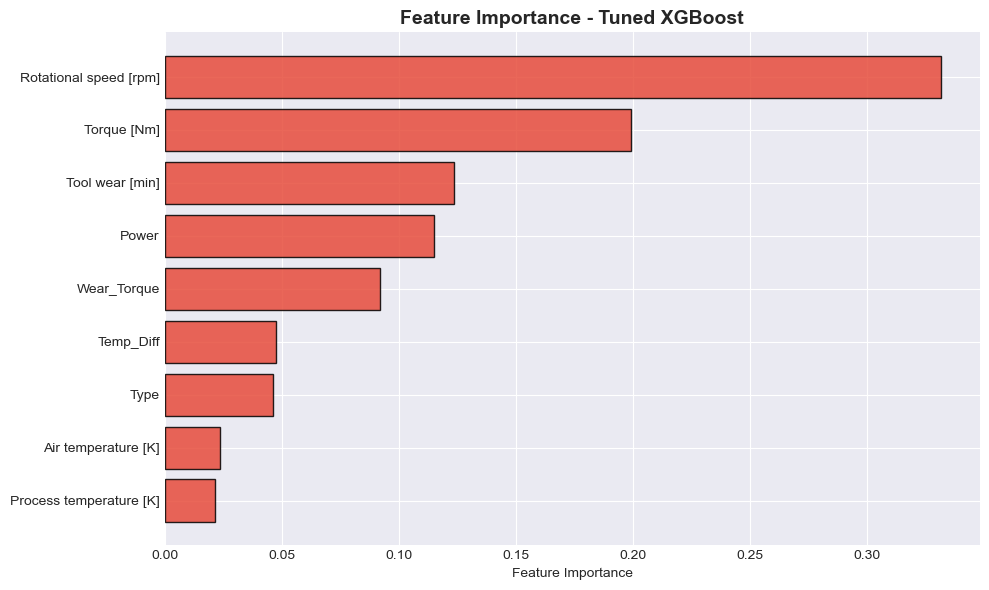

In [42]:
# XGBoost feature importance

xgb_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_xgb.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(xgb_imp['Feature'], xgb_imp['Importance'],
         color='#e74c3c', edgecolor='black', alpha=0.85)
plt.xlabel('Feature Importance')
plt.title('Feature Importance - Tuned XGBoost', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

### Final Model Comparison and Conclusions
---

In [43]:
#  Add tuned XGBoost to results

tuned_row = pd.DataFrame([{
    'Model': 'XGBoost (Tuned)',
    'Accuracy': round(accuracy_score(y_test, y_pred_tuned)*100, 2),
    'Precision': round(precision_score(y_test, y_pred_tuned), 4),
    'Recall': round(recall_score(y_test, y_pred_tuned), 4),
    'F1 Score': round(f1_score(y_test, y_pred_tuned), 4),
    'ROC-AUC': round(roc_auc_score(y_test, y_prob_tuned), 4)
}])

final_results = pd.concat([results_df, tuned_row], ignore_index=True)
final_results = final_results.sort_values('ROC-AUC', ascending=False)


print('FINAL MODEL COMPARISON REPORT')

print(final_results.to_string(index=False))

FINAL MODEL COMPARISON REPORT
              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
  Gradient Boosting     94.60     0.3750  0.8824    0.5263   0.9746
            XGBoost     97.20     0.5652  0.7647    0.6500   0.9712
    XGBoost (Tuned)     97.30     0.5833  0.7206    0.6447   0.9711
      Random Forest     96.90     0.5300  0.7794    0.6310   0.9704
                SVM     92.10     0.2857  0.8824    0.4317   0.9659
Logistic Regression     85.75     0.1742  0.8529    0.2893   0.9311
                KNN     93.05     0.2924  0.7353    0.4184   0.8729


In [46]:
# Final conclusions

best = final_results.iloc[0]

print('PREDICTIVE MAINTENANCE - FINAL CONCLUSIONS')

print(f'\nBEST MODEL: {best["Model"]}')
print(f'  Accuracy:  {best["Accuracy"]:.2f}%')
print(f'  Recall:    {best["Recall"]:.4f} (catches {best["Recall"]*100:.1f}% of failures)')
print(f'  Precision: {best["Precision"]:.4f}')
print(f'  F1 Score:  {best["F1 Score"]:.4f}')
print(f'  ROC-AUC:   {best["ROC-AUC"]:.4f}')
print()
print('KEY FINDINGS:')
print('  1. Class imbalance (96.6% vs 3.4%) was the main challenge')
print('  2. SMOTE successfully balanced training data')
print('  3. Torque and Tool wear are strongest failure predictors')
print('  4. Engineered features (Power, Wear_Torque) improved predictions')
print('  5. Ensemble methods outperformed linear models')
print('  6. Recall is prioritized - missing a failure is costlier than false alarm')
print()
print('CLINICAL/INDUSTRIAL RELEVANCE:')
print('  Predictive maintenance prevents unplanned downtime')
print('  In medical equipment (linacs, CT scanners): critical for patient safety')
print('  Early failure detection = reduced repair costs + zero treatment delays')


PREDICTIVE MAINTENANCE - FINAL CONCLUSIONS

BEST MODEL: Gradient Boosting
  Accuracy:  94.60%
  Recall:    0.8824 (catches 88.2% of failures)
  Precision: 0.3750
  F1 Score:  0.5263
  ROC-AUC:   0.9746

KEY FINDINGS:
  1. Class imbalance (96.6% vs 3.4%) was the main challenge
  2. SMOTE successfully balanced training data
  3. Torque and Tool wear are strongest failure predictors
  4. Engineered features (Power, Wear_Torque) improved predictions
  5. Ensemble methods outperformed linear models
  6. Recall is prioritized - missing a failure is costlier than false alarm

CLINICAL/INDUSTRIAL RELEVANCE:
  Predictive maintenance prevents unplanned downtime
  In medical equipment (linacs, CT scanners): critical for patient safety
  Early failure detection = reduced repair costs + zero treatment delays


In [47]:
# Save best model

import pickle
with open('best_maintenance_model.pkl', 'wb') as f:
    pickle.dump(best_xgb, f)
with open('scaler_maintenance.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('Best model saved: best_maintenance_model.pkl')
print('Scaler saved: scaler_maintenance.pkl')

Best model saved: best_maintenance_model.pkl
Scaler saved: scaler_maintenance.pkl


**App Link :**  https://predictive-maintenance-by-vineeth.streamlit.app/

**GitHub Link :**  https://github.com/Vineeth-Muraleedharan/-predictive-maintenance